In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [10]:
file_path = "mitbih_train.csv"

path = kagglehub.dataset_download("taejoongyoon/mitbit-arrhythmia-database")



100%|██████████| 288M/288M [02:29<00:00, 2.02MB/s] 

Extracting files...


In [11]:
print(path)

C:\Users\aashr\.cache\kagglehub\datasets\taejoongyoon\mitbit-arrhythmia-database\versions\1


In [12]:
import os

print(os.listdir(path))

['mitbih_database']


In [16]:
ecg_path = os.path.join(path, "mitbih_database")

df = pd.read_csv(os.path.join(ecg_path, "100.csv"))

print(df.head())
print(df.shape)

   'sample #'  'MLII'  'V5'
0           0     995  1011
1           1     995  1011
2           2     995  1011
3           3     995  1011
4           4     995  1011
(650000, 3)


In [19]:
df.columns

Index([''sample #'', ''MLII'', ''V5''], dtype='str')

In [21]:
df2 = pd.read_csv(os.path.join(ecg_path, "101.csv"))
df2.head()

,'sample #','MLII','V1'
0,0,955,992
1,1,955,992
2,2,955,992
3,3,955,992
4,4,955,992


In [22]:
df.columns = ["sample", "MLII", "V5"]
print(df.head())

   sample  MLII    V5
0       0   995  1011
1       1   995  1011
2       2   995  1011
3       3   995  1011
4       4   995  1011


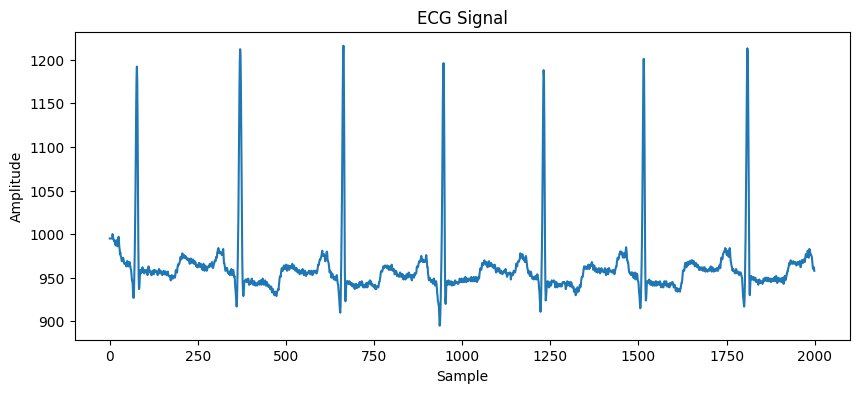

In [25]:
plt.figure(figsize=(10,4))
plt.plot(df["MLII"][:2000])
plt.title("ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [39]:
ann = pd.read_csv(
    os.path.join(ecg_path, "100annotations.txt"),
    sep="\s+",
    header=0
)

print(ann.head())

       Time  Sample  #  Type  Sub  Chan  Num  Aux
0  0:00.050      18  +     0    0     0   (N  NaN
1  0:00.214      77  N     0    0     0  NaN  NaN
2  0:01.028     370  N     0    0     0  NaN  NaN
3  0:01.839     662  N     0    0     0  NaN  NaN
4  0:02.628     946  N     0    0     0  NaN  NaN


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\aashr\AppData\Local\Temp\ipykernel_23804\1790851724.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


In [40]:
ann.iloc[0,:]

Time      0:00.050
Sample          18
#                +
Type             0
Sub              0
Chan             0
Num             (N
Aux            NaN
Name: 0, dtype: object

In [41]:
ann = ann[['Sample', '#']]
ann.columns = ['Sample', 'Label']

print(ann.head())

   Sample Label
0      18     +
1      77     N
2     370     N
3     662     N
4     946     N


In [44]:
print(ann.shape)
ann=ann[ann['Label']!='+']
print(ann.shape)

(2274, 2)
(2273, 2)


In [45]:
window = 100
signals = []
labels = []

for _, row in ann.iterrows():

    r = int(row['Sample'])
    label = row['Label']

    start = r - window
    end = r + window

    if start > 0 and end < len(df):

        beat = df['MLII'].iloc[start:end].values
        signals.append(beat)
        labels.append(label)

In [46]:
X = np.array(signals)
y = np.array(labels)

print(X.shape)

(2271, 200)


In [62]:
print(np.sum(ann['Label']=='N'))

2700


In [63]:
ann.shape

(2761, 2)

In [55]:
import os

records = [f.split(".")[0] for f in os.listdir(ecg_path) if f.endswith(".csv")]

print(records[:])

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [57]:
signals = []
labels = []

window = 100

for record in records:

    df = pd.read_csv(os.path.join(ecg_path, f"{record}.csv"))
    df.columns = ["sample","MLII","V5"]

    ann = pd.read_csv(
        os.path.join(ecg_path, f"{record}annotations.txt"),
        sep=r"\s+",
        engine="python",
        on_bad_lines="skip"
    )

    ann = ann[['Sample','#']]
    ann.columns = ['Sample','Label']

    ann = ann[ann['Label']!='+']

    for _, row in ann.iterrows():

        r = int(row['Sample'])
        label = row['Label']

        start = r-100
        end = r+100

        if start>0 and end<len(df):

            beat = df['MLII'].iloc[start:end].values
            signals.append(beat)
            labels.append(label)

In [64]:
X = np.array(signals)
y = np.array(labels)

print(X.shape)
print(y.shape)

(111322, 200)
(111322,)


In [59]:
valid_labels = ['N','A','V','F','L','R']

mask = np.isin(y, valid_labels)

X = X[mask]
y = y[mask]

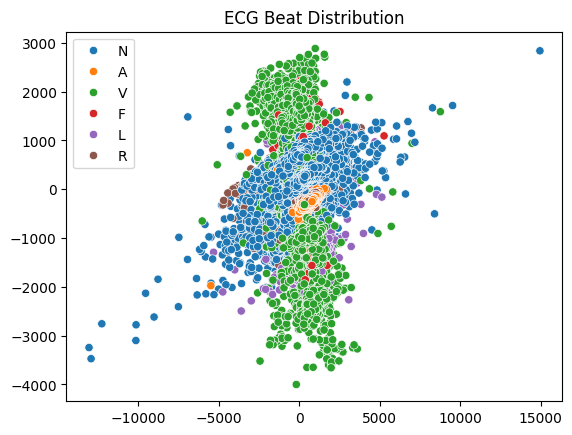

In [60]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y)

plt.title("ECG Beat Distribution")
plt.show()

In [73]:
print(np.sum(y=='N'))
print(np.sum(y=='A'))
print(np.sum(y=='V'))
print(np.sum(y=='F'))
print(np.sum(y=='L'))
print(np.sum(y=='R'))

75028
2546
7129
802
8073
7257


In [77]:
X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [78]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

ros = RandomOverSampler(
    sampling_strategy={
        'N':75028,
        'A':75028,
        'V':75028,
        'F':75028,
        'L':75028,
        'R':75028
    },
    random_state=42
)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print(X_resampled.shape)

(457509, 200)


In [79]:
import collections
print(collections.Counter(y_resampled))

Counter({np.str_('R'): 75028, np.str_('N'): 75028, np.str_('V'): 75028, np.str_('L'): 75028, np.str_('A'): 75028, np.str_('F'): 75028, np.str_('/'): 4918, np.str_('f'): 687, np.str_('~'): 430, np.str_('!'): 331, np.str_('"'): 306, np.str_('j'): 160, np.str_('x'): 135, np.str_('a'): 105, np.str_('|'): 93, np.str_('E'): 74, np.str_('J'): 58, np.str_('Q'): 23, np.str_('e'): 11, np.str_(']'): 4, np.str_('['): 4, np.str_('S'): 2})


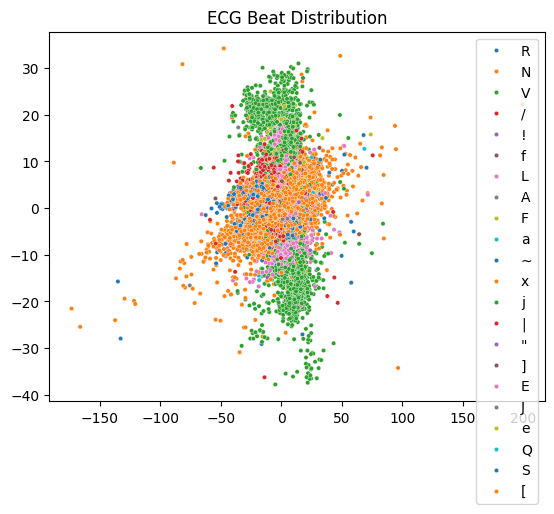

In [84]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette='tab10', s=10)

plt.title("ECG Beat Distribution")
plt.show()

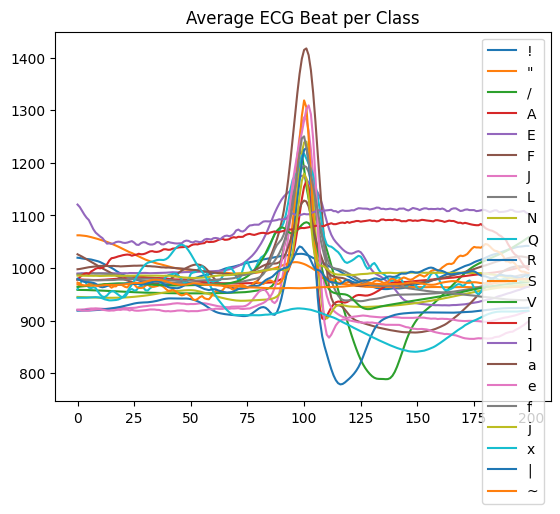

In [85]:
import numpy as np

for label in np.unique(y_train):

    mean_beat = X_train[y_train == label].mean(axis=0)

    plt.plot(mean_beat, label=label)

plt.legend()
plt.title("Average ECG Beat per Class")
plt.show()

In [86]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.9717938737012306
